# 02 Feature Validation and Modeling
This notebook validates engineered features from the pipeline, performs multicollinearity and target-correlation diagnostics, trains forecasting models, and produces explainability outputs.


In [60]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv
from IPython.display import Markdown, display

import warnings
warnings.filterwarnings('ignore')

os.environ['LIGHTGBM_VERBOSITY'] = '-1'

is_nb = 'notebooks' in os.getcwd()
PROJECT_ROOT = os.path.abspath('..' if is_nb else '.')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')
sys.path.append(PROJECT_ROOT)
load_dotenv(os.path.join(PROJECT_ROOT, '.env'))

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'grid.color': '#e1e4e8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'axes.edgecolor': '#d1d5da',
    'axes.labelcolor': '#24292e',
    'xtick.color': '#586069',
    'ytick.color': '#586069',
    'text.color': '#24292e'
})

from src.features import FeaturePipeline
from src.feature_eng import FeatureEngineer, REDUNDANT_MACRO_BASES
from src.models import MacroFinanceModels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print('Notebook environment configured.')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Notebook environment configured.


## 2.1 Pipeline Execution and Engineered Feature Set
Run ingestion and feature engineering, then inspect the processed dataset.


In [61]:
pipeline = FeaturePipeline()
df_processed = pipeline.run_pipeline(start_date='2000-01-01')

print('Processed data shape:', df_processed.shape)
display(df_processed.head())
print('Processed dataset path:', pipeline.processed_file_path())


Processed data shape: (303, 42)


,FEDFUNDS,CPIAUCSL,T10Y2Y,UNRATE,SP500,SP500_log,SP500_ret,target_next_ret,SP500_mom_3m,SP500_mom_6m,...,CPI_acceleration_lag3,UNRATE_diff_lag1,UNRATE_diff_lag2,UNRATE_diff_lag3,T10Y2Y_diff_lag1,T10Y2Y_diff_lag2,T10Y2Y_diff_lag3,real_rate_proxy_lag1,real_rate_proxy_lag2,real_rate_proxy_lag3
date,,,,,,,,,,,,,,,,,,,,,
2001-04-01,4.80,176.4,1.05,4.4,1249.459961,7.130467,0.074007,0.005077,-0.089183,-0.134543,...,0.003431,0.1,0.0,0.3,0.24,-0.06,0.56,5.280175,5.454706,5.942788
2001-05-01,4.21,177.3,1.21,4.3,1255.819946,7.135544,0.005077,-0.025354,0.012726,-0.046010,...,-0.003449,0.1,0.1,0.0,0.30,0.24,-0.06,4.767817,5.280175,5.454706
2001-06-01,3.97,177.7,1.17,4.5,1224.380005,7.110190,-0.025354,-0.010798,0.053730,-0.075409,...,-0.001710,-0.1,0.1,0.1,0.16,0.30,0.24,4.174369,4.767817,5.280175
2001-07-01,3.77,177.4,1.28,4.6,1211.229980,7.099392,-0.010798,-0.066256,-0.031075,-0.120258,...,0.001135,0.2,-0.1,0.1,-0.04,0.16,0.30,3.938060,4.174369,4.767817
2001-08-01,3.65,177.4,1.21,4.9,1133.579956,7.033136,-0.066256,-0.085257,-0.102408,-0.089682,...,0.003398,0.1,0.2,-0.1,0.11,-0.04,0.16,3.742785,3.938060,4.174369


Processed dataset path: C:\Users\İlyas\OneDrive\Desktop\macro-finance-prediction\data\processed\macro_finance_engineered.csv


## 2.2 Multicollinearity Diagnostics
Evaluate feature multicollinearity with VIF and identify redundant predictors.


In [62]:
excluded_cols = ['FEDFUNDS', 'CPIAUCSL', 'T10Y2Y', 'UNRATE', 'SP500', 'SP500_log', 'target_next_ret']
feature_cols = [col for col in df_processed.columns if col not in excluded_cols]
X_vif = df_processed[feature_cols].copy()
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_results = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)

print('Top 10 VIF values:')
display(vif_results.head(10))
print('Safe predictors (VIF < 5):')
display(vif_results[vif_results['VIF'] < 5.0])


Top 10 VIF values:


,Feature,VIF
9,CPI_inflation_mom,inf
10,CPI_inflation_yoy,inf
11,CPI_acceleration,inf
33,real_rate_proxy_lag1,inf
34,real_rate_proxy_lag2,inf
25,CPI_acceleration_lag2,inf
8,FEDFUNDS_diff,inf
16,FEDFUNDS_diff_lag2,inf
18,CPI_inflation_mom_lag1,inf
14,real_rate_proxy,inf


Safe predictors (VIF < 5):


,Feature,VIF
7,SP500_vol_12m,4.100731
4,SP500_mom_12m,4.048795
2,SP500_mom_3m,3.494501
5,SP500_vol_3m,3.227318
17,FEDFUNDS_diff_lag3,3.205249
26,CPI_acceleration_lag3,1.916526
1,SP500_ret,1.783667
27,UNRATE_diff_lag1,1.440416
12,UNRATE_diff,1.433308
32,T10Y2Y_diff_lag3,1.358959


## 2.3 Target Correlation and Predictor Ranking
Rank engineered predictors by absolute correlation with the one-period-ahead return target.


In [63]:
correlations = df_processed[feature_cols].apply(lambda x: x.corr(df_processed['target_next_ret']))
corr_df = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
})
corr_df['AbsCorrelation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values(by='AbsCorrelation', ascending=False).reset_index(drop=True)

print('Top 15 predictors by absolute correlation with target:')
display(corr_df.head(15))


Top 15 predictors by absolute correlation with target:


,Feature,Correlation,AbsCorrelation
0,CPI_inflation_yoy,-0.147817,0.147817
1,FEDFUNDS_diff_lag2,0.139411,0.139411
2,CPI_inflation_yoy_lag2,-0.138691,0.138691
3,CPI_inflation_yoy_lag1,-0.137731,0.137731
4,CPI_inflation_yoy_lag3,-0.129149,0.129149
5,CPI_acceleration_lag1,0.126359,0.126359
6,FEDFUNDS_diff_lag3,0.120532,0.120532
7,CPI_inflation_mom_lag3,-0.115291,0.115291
8,CPI_inflation_mom_lag2,-0.083648,0.083648
9,SP500_vol_12m,0.073956,0.073956


## 2.4 Refined Feature Set for Modeling
Remove redundant features flagged by VIF and domain logic, then re-evaluate the candidate set.


In [64]:
redundant_cols = []
for base in REDUNDANT_MACRO_BASES:
    redundant_cols.append(base)
    for lag in [1, 2, 3]:
        redundant_cols.append(f'{base}_lag{lag}')

refined_features = [col for col in feature_cols if col not in redundant_cols]
X_refined = df_processed[refined_features].copy()
X_refined = add_constant(X_refined)

vif_refined = pd.DataFrame({
    'Feature': X_refined.columns,
    'VIF': [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
})
vif_refined = vif_refined[vif_refined['Feature'] != 'const'].sort_values(by='VIF', ascending=False)

print('Refined feature set VIF analysis:')
display(vif_refined)


Refined feature set VIF analysis:


,Feature,VIF
6,SP500_vol_6m,5.686506
3,SP500_mom_6m,5.672179
7,SP500_vol_12m,3.860396
4,SP500_mom_12m,3.480052
2,SP500_mom_3m,3.344008
5,SP500_vol_3m,3.150275
12,CPI_inflation_mom_lag2,2.032574
11,CPI_inflation_mom_lag1,1.988489
1,SP500_ret,1.713293
13,CPI_inflation_mom_lag3,1.521488


## 2.5 Modeling Preparation
Prepare time-ordered training and test splits from the engineered dataset, preserving temporal integrity.


In [65]:
engineer = FeatureEngineer()
X_train, X_test, y_train, y_test, feature_cols, scaler = engineer.prepare_modeling_data(test_size=0.2)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Feature count:', len(feature_cols))
print('Top features for modeling:')
display(pd.DataFrame({'Feature': feature_cols}).head(20))


Train shape: (242, 19)
Test shape: (61, 19)
Feature count: 19
Top features for modeling:


,Feature
0,SP500_ret
1,SP500_mom_3m
2,SP500_mom_6m
3,SP500_mom_12m
4,SP500_vol_3m
5,SP500_vol_6m
6,SP500_vol_12m
7,CPI_inflation_mom
8,UNRATE_diff
9,T10Y2Y_diff


## 2.6 Model Training and Evaluation
Train baseline and regularized regressors with time-series cross-validation, then extend the comparison with boosting models and financial metrics.


In [66]:
model_pipeline = MacroFinanceModels(random_state=42)
df_metrics, df_predictions = model_pipeline.fit_and_evaluate(X_train, X_test, y_train, y_test)

print('=== Predictive Performance Matrix ===')
display(df_metrics.round(5))
print('Prediction columns:', list(df_predictions.columns))

# Keep the comparison table in a consistent order and format.
df_metrics = df_metrics.sort_values(by='Test_R2', ascending=False).reset_index(drop=True)

comparison_df = pd.DataFrame({
    'Model': df_metrics['Model'],
    'Train R²': df_metrics['Train_R2'],
    'Test R²': df_metrics['Test_R2'],
    'Train RMSE': df_metrics['Train_RMSE'],
    'Test RMSE': df_metrics['Test_RMSE'],
    'Train MAE': df_metrics['Train_MAE'],
    'Test MAE': df_metrics['Test_MAE'],
    'Directional Accuracy': df_metrics['Test_Directional_Accuracy'],
}).sort_values(by='Test R²', ascending=False).reset_index(drop=True)

comparison_table = comparison_df.style.format({
    'Train R²': '{:.4f}',
    'Test R²': '{:.4f}',
    'Train RMSE': '{:.4f}',
    'Test RMSE': '{:.4f}',
    'Train MAE': '{:.4f}',
    'Test MAE': '{:.4f}',
    'Directional Accuracy': '{:.2f}%',
}).highlight_max(subset=['Test R²'], color='#d4edda')

display(comparison_table)

best_model_name = comparison_df.loc[0, 'Model']

best_model_summary = (
    f"The best-performing model is **{best_model_name}** with a test R² of "
    f"{comparison_df.loc[0, 'Test R²']:.4f} and directional accuracy of "
    f"{comparison_df.loc[0, 'Directional Accuracy']:.2f}%."
)
print(best_model_summary)


=== Predictive Performance Matrix ===


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_Directional_Accuracy,Test_Directional_Accuracy,Alpha,L1_ratio,Best_Params
0,Baseline,0.00000,-0.00842,0.04292,0.04507,0.03139,0.03696,64.04959,62.29508,NaN,NaN,NaN
1,ElasticNetCV,0.00000,-0.00842,0.04292,0.04507,0.03139,0.03696,64.04959,62.29508,1.125000e-02,0.9,NaN
2,RidgeCV,0.00000,-0.00842,0.04292,0.04507,0.03139,0.03696,64.04959,62.29508,1.000000e+08,NaN,NaN
3,OLS,0.07205,-0.12688,0.04134,0.04764,0.03052,0.03779,61.98347,59.01639,NaN,NaN,NaN
4,XGBoost,0.46878,-0.13445,0.03128,0.04780,0.02420,0.03972,78.92562,44.26230,NaN,NaN,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
5,LightGBM,0.29525,-0.15996,0.03603,0.04834,0.02705,0.03977,75.20661,45.90164,NaN,NaN,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
6,MLP,-7.20741,-5.07386,0.12296,0.11061,0.02648,0.07857,85.12397,50.81967,NaN,NaN,NaN


Prediction columns: ['Actual', 'Baseline_Pred', 'OLS_Pred', 'RidgeCV_Pred', 'ElasticNetCV_Pred', 'MLP_Pred', 'XGBoost_Pred', 'LightGBM_Pred']


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,Directional Accuracy
0,Baseline,0.0000,-0.0084,0.0429,0.0451,0.0314,0.0370,62.30%
1,ElasticNetCV,0.0000,-0.0084,0.0429,0.0451,0.0314,0.0370,62.30%
2,RidgeCV,0.0000,-0.0084,0.0429,0.0451,0.0314,0.0370,62.30%
3,OLS,0.0720,-0.1269,0.0413,0.0476,0.0305,0.0378,59.02%
4,XGBoost,0.4688,-0.1344,0.0313,0.0478,0.0242,0.0397,44.26%
5,LightGBM,0.2953,-0.1600,0.0360,0.0483,0.0270,0.0398,45.90%
6,MLP,-7.2074,-5.0739,0.1230,0.1106,0.0265,0.0786,50.82%


The best-performing model is **Baseline** with a test R² of -0.0084 and directional accuracy of 62.30%.


## 2.7 Gradient Boosting Models
The training loop now evaluates conservative gradient-boosted regressors with time-series cross-validation, adds directional accuracy to the financial performance matrix, and ranks models by out-of-sample fit.


## 2.7 Model Comparison
Review the final ranking of models by out-of-sample performance and directional accuracy.

### Financial Metrics
The comparison table below reports R², RMSE, MAE, and directional accuracy for each model.


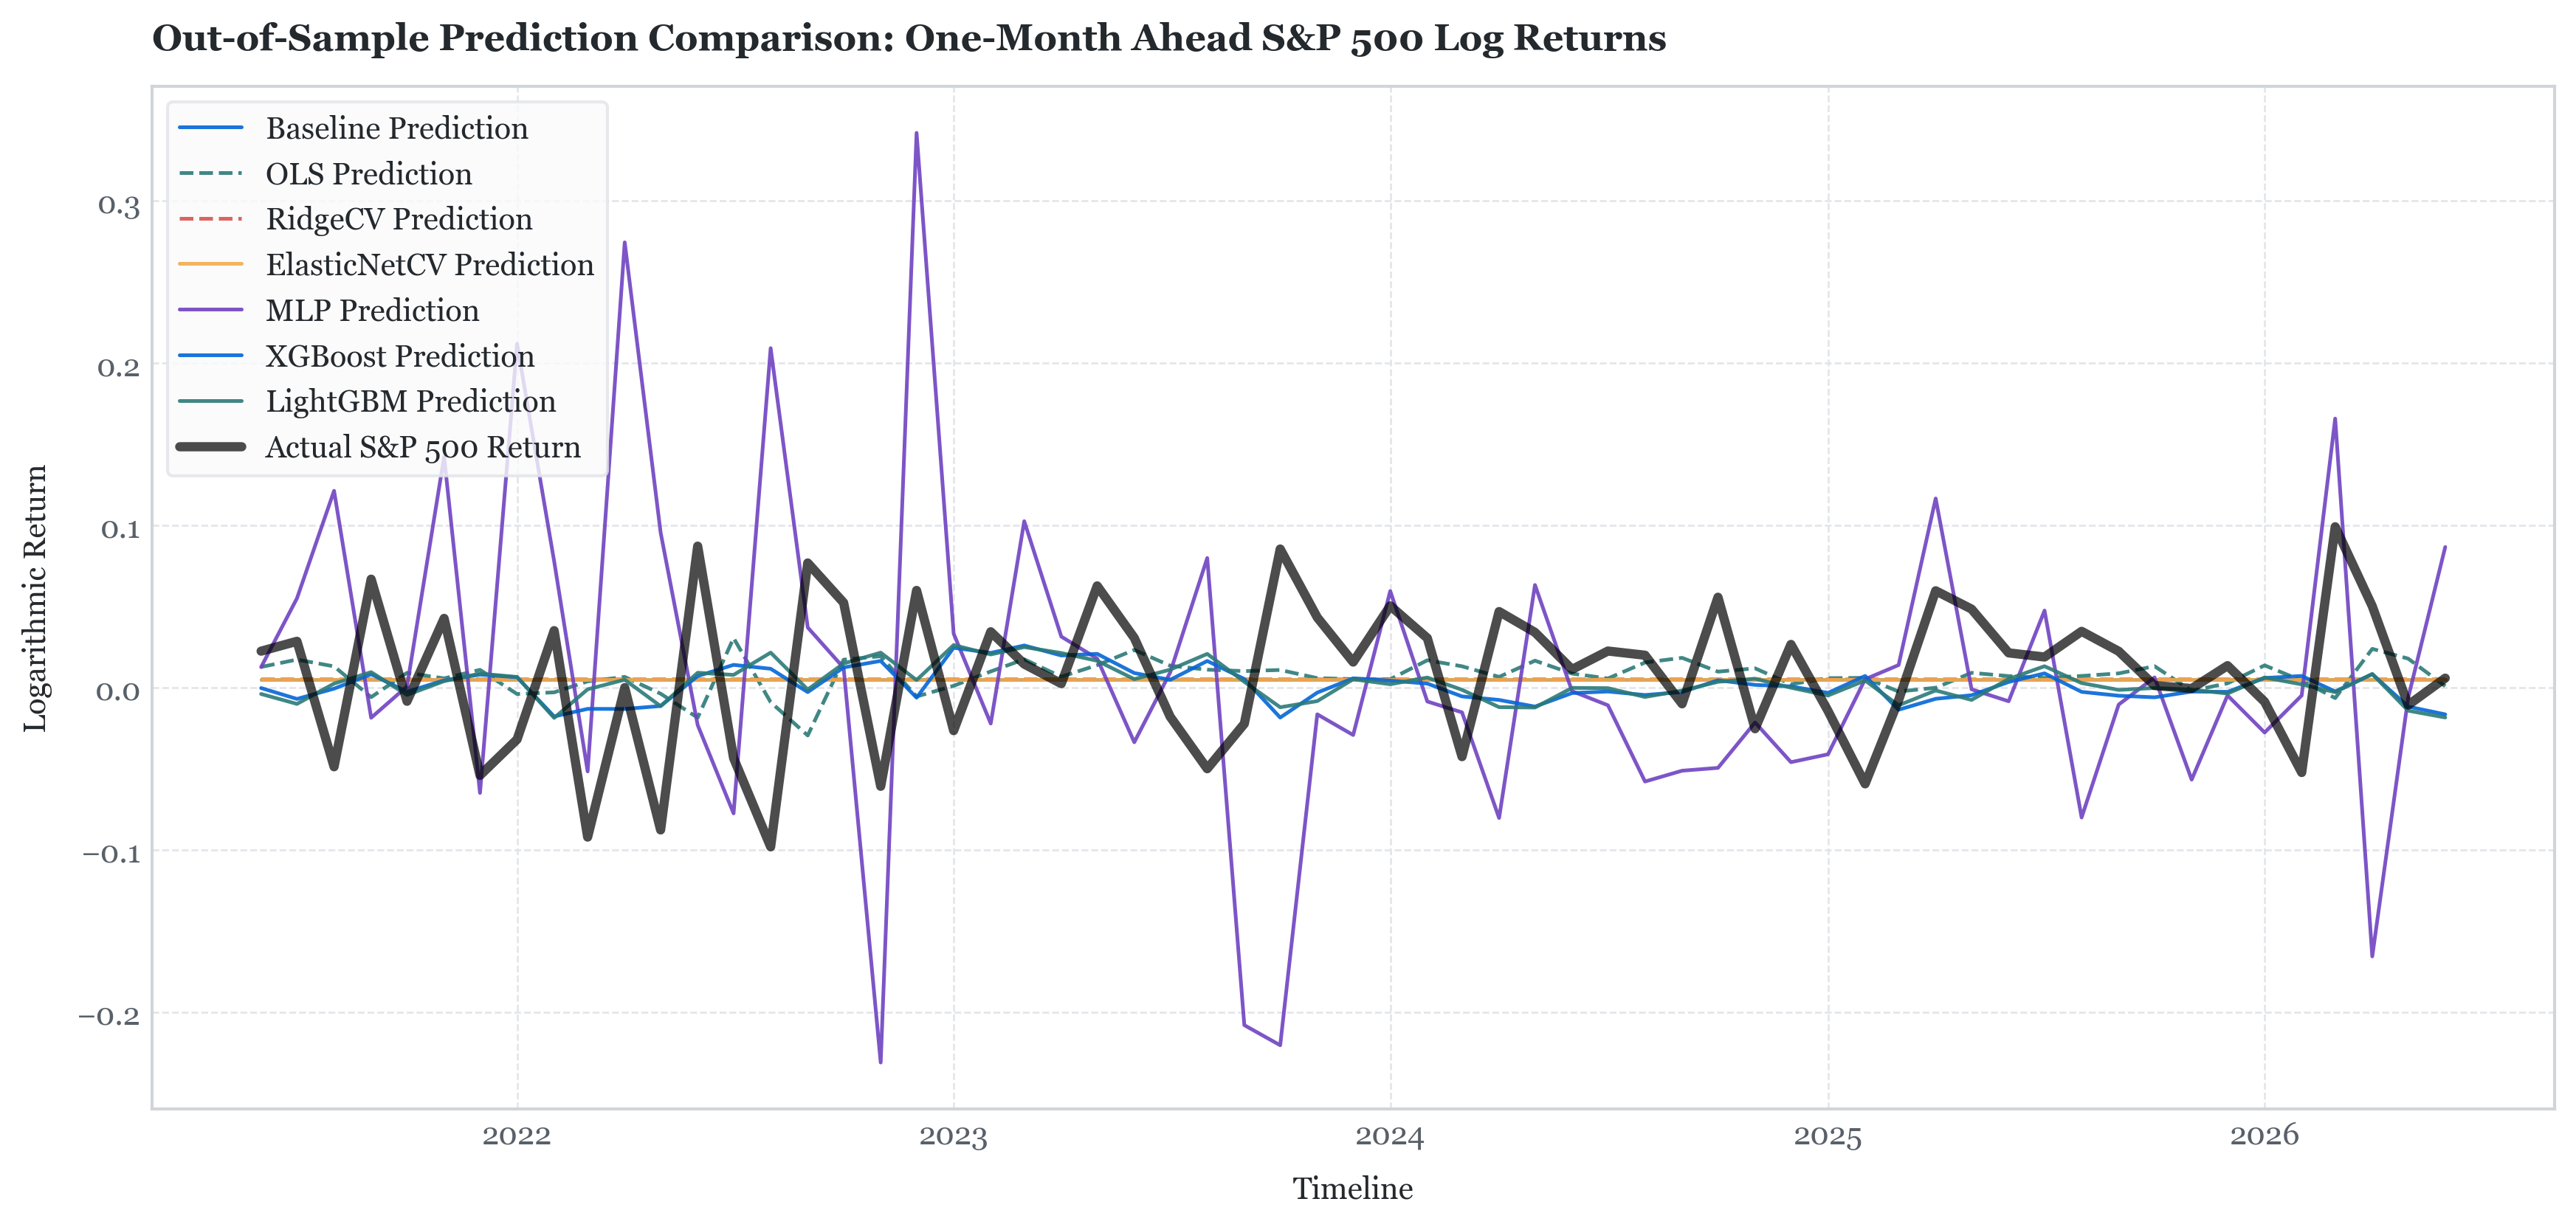

In [67]:
plt.figure(figsize=(14, 6), dpi=300)

prediction_models = [col for col in df_predictions.columns if col.endswith('_Pred')]
plot_colors = ['#0366d6', '#2b7a78', '#d9534f', '#f0ad4e', '#6f42c1']

for idx, model_col in enumerate(prediction_models):
    model_name = model_col.replace('_Pred', '')
    if model_name == 'Actual':
        continue
    plt.plot(
        df_predictions.index,
        df_predictions[model_col],
        label=f'{model_name} Prediction',
        color=plot_colors[idx % len(plot_colors)],
        linestyle='--' if model_name in {'OLS', 'RidgeCV'} else '-',
        linewidth=1.2,
        alpha=0.9,
    )

plt.plot(df_predictions.index, df_predictions['Actual'], label='Actual S&P 500 Return', color="#000000", linewidth=3, alpha=0.7)

plt.title('Out-of-Sample Prediction Comparison: One-Month Ahead S&P 500 Log Returns', loc='left', fontsize=12, fontweight='bold', color='#24292e', pad=12)
plt.xlabel('Timeline', fontsize=10, labelpad=8)
plt.ylabel('Logarithmic Return', fontsize=10, labelpad=8)
plt.legend(loc='upper left', frameon=True, facecolor='#fafbfc', edgecolor='#e1e4e8')
plt.grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)

os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURES_DIR, 'model_predictions_comparison.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()


## 2.8 Residual Diagnostics
Inspect forecast errors for the best-performing model to detect systematic bias and time-structure in residuals.


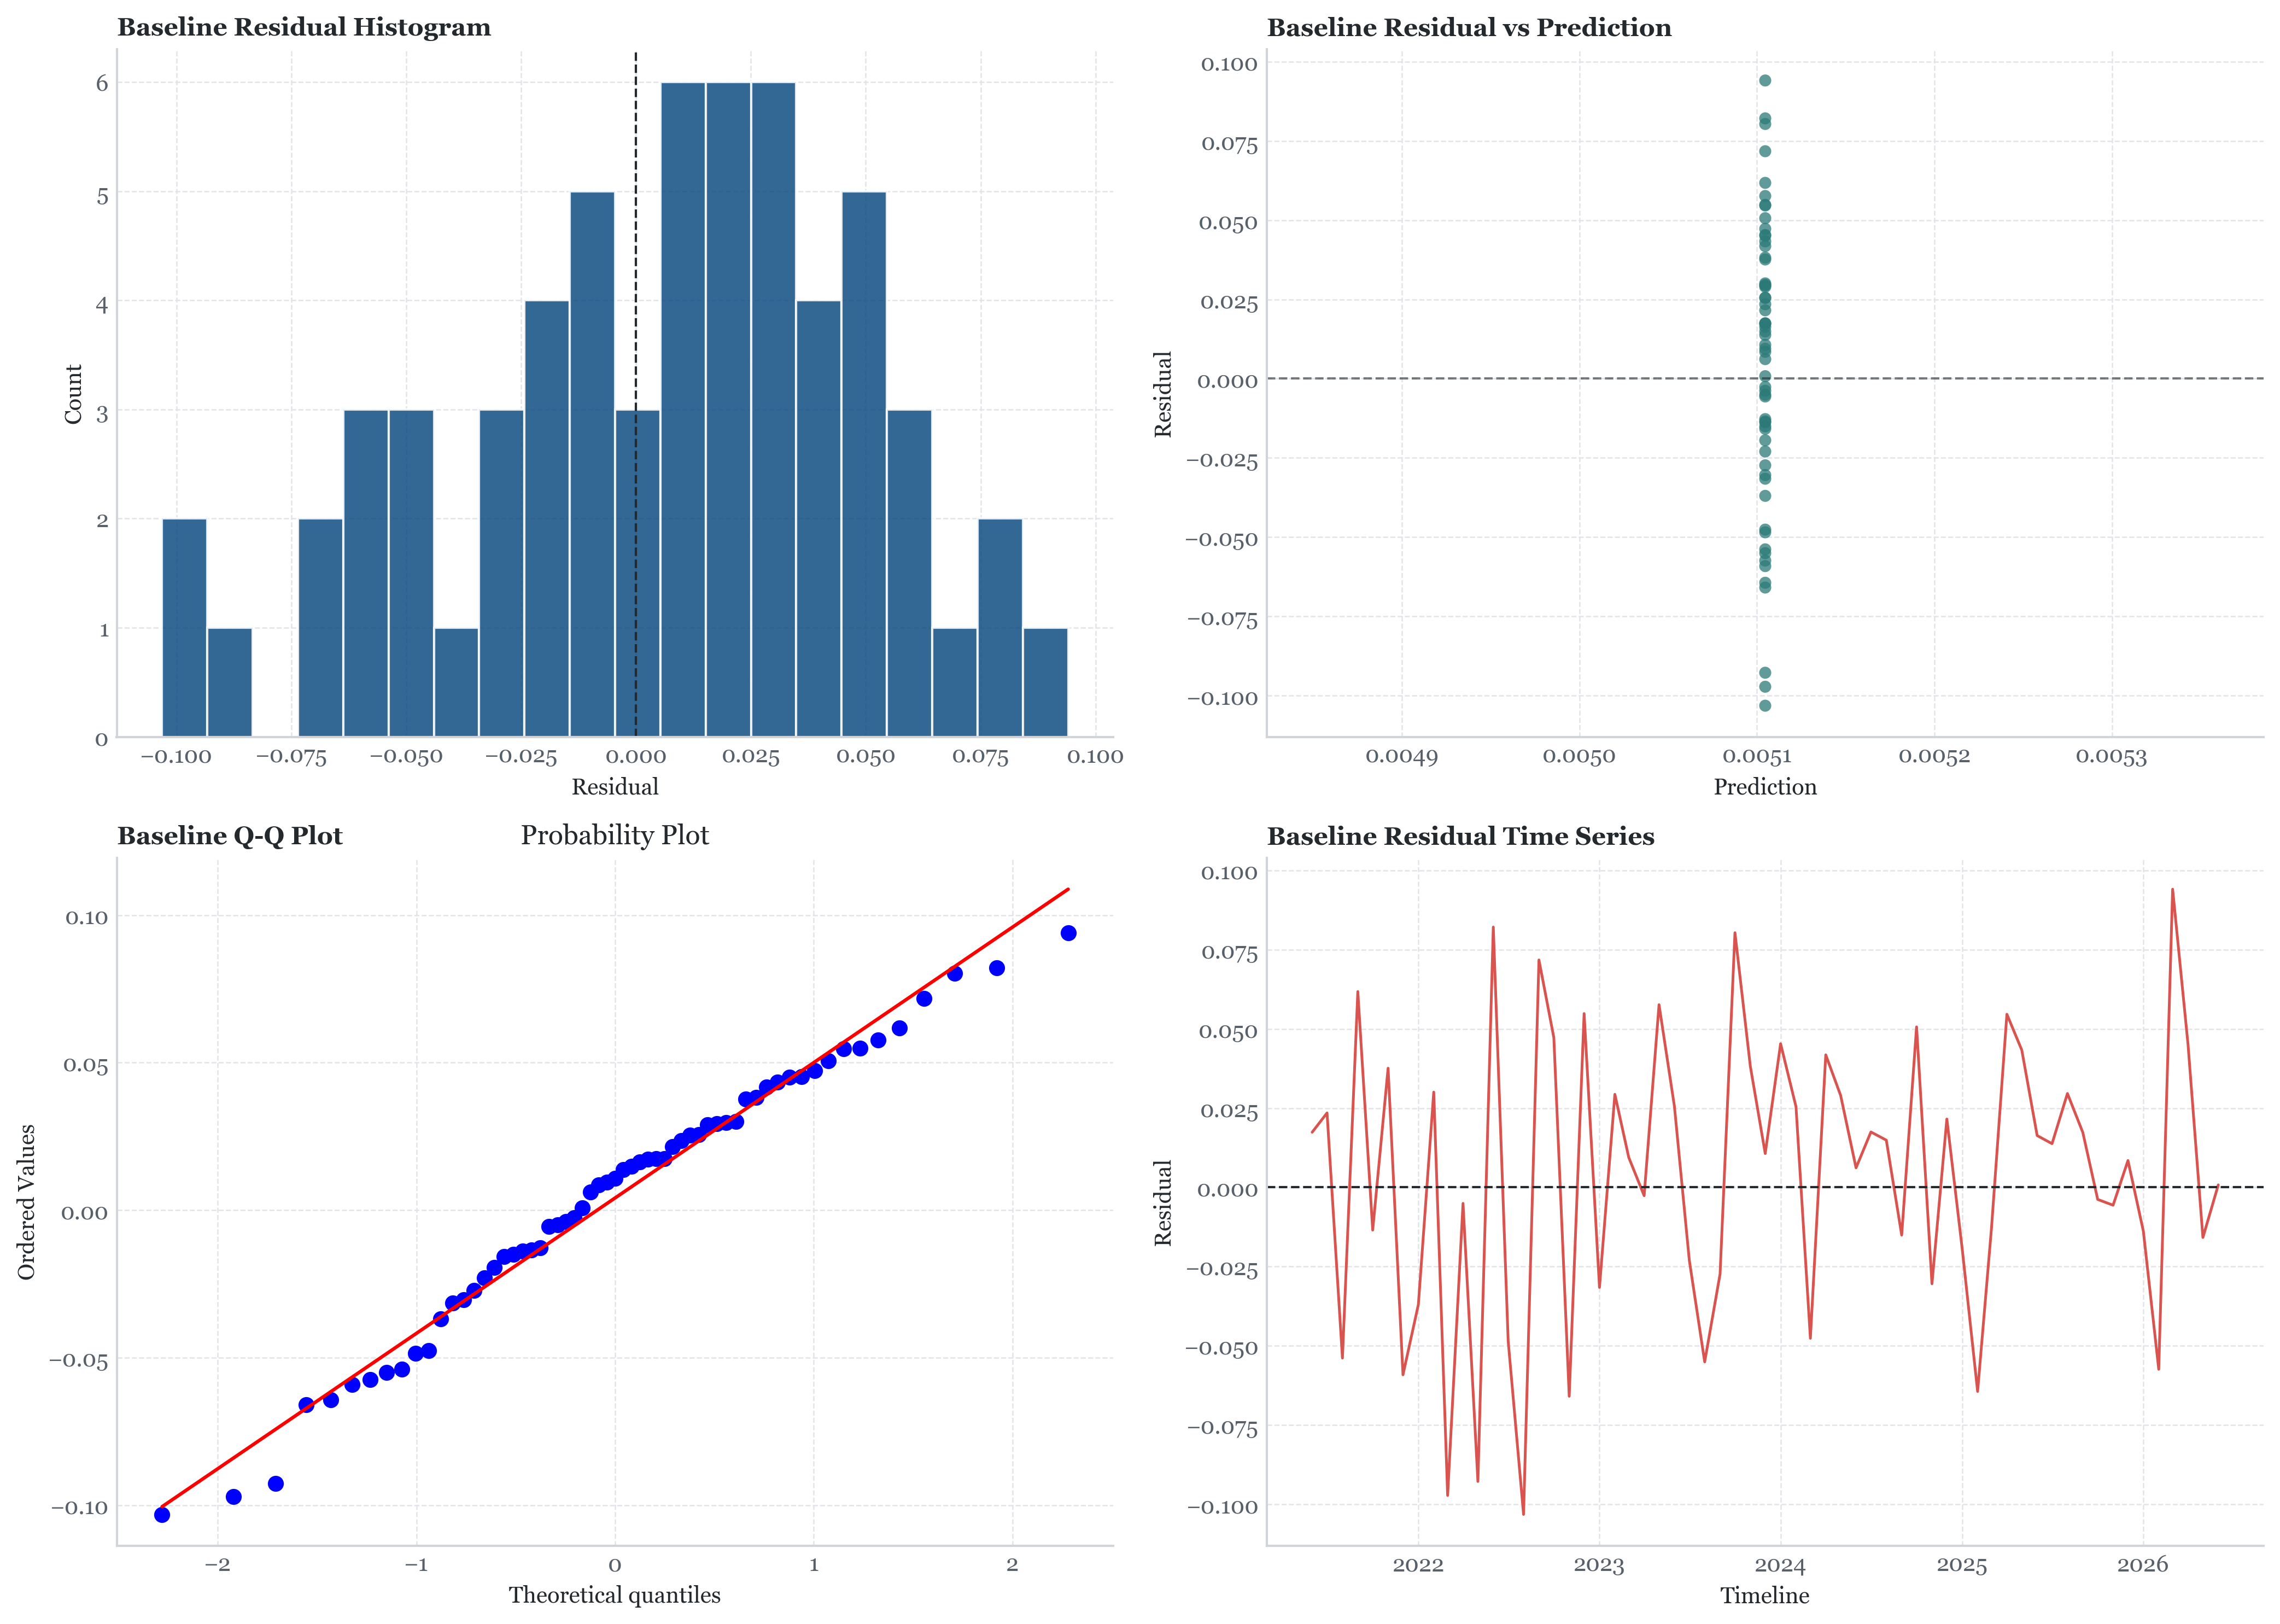

In [68]:
from scipy import stats

best_pred_col = f'{best_model_name}_Pred'
residuals = df_predictions['Actual'] - df_predictions[best_pred_col]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
fig.patch.set_facecolor('#ffffff')

axes[0, 0].hist(residuals, bins=20, color='#0f4c81', edgecolor='#ffffff', alpha=0.85)
axes[0, 0].axvline(0, color='#24292e', linestyle='--', linewidth=1.0)
axes[0, 0].set_title(f'{best_model_name} Residual Histogram', loc='left', fontsize=11, fontweight='semibold', color='#24292e')
axes[0, 0].set_xlabel('Residual')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)

axes[0, 1].scatter(df_predictions[best_pred_col], residuals, color='#2b7a78', alpha=0.75, s=28, edgecolors='none')
axes[0, 1].axhline(0, color='#24292e', linewidth=1.0, linestyle='--', alpha=0.6)
axes[0, 1].set_title(f'{best_model_name} Residual vs Prediction', loc='left', fontsize=11, fontweight='semibold', color='#24292e')
axes[0, 1].set_xlabel('Prediction')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)

stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title(f'{best_model_name} Q-Q Plot', loc='left', fontsize=11, fontweight='semibold', color='#24292e')
axes[1, 0].grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)

axes[1, 1].plot(df_predictions.index, residuals, color='#d9534f', linewidth=1.2)
axes[1, 1].axhline(0, color='#24292e', linestyle='--', linewidth=1.0)
axes[1, 1].set_title(f'{best_model_name} Residual Time Series', loc='left', fontsize=11, fontweight='semibold', color='#24292e')
axes[1, 1].set_xlabel('Timeline')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)

for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'best_model_residual_diagnostics.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()


## 2.9 Explainable AI (XAI)
Rank macro-finance drivers via permutation importance for the MLP model, then extend the analysis to gradient boosting models with SHAP-based summaries.


In [69]:
from sklearn.inspection import permutation_importance

mlp_model = model_pipeline.trained_models['MLP']
result = permutation_importance(
    mlp_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

df_xai = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std,
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print('=== XAI: MLP Feature Importance (Top 10 Drivers) ===')
display(df_xai.head(10).round(5))


=== XAI: MLP Feature Importance (Top 10 Drivers) ===


,Feature,Importance_Mean,Importance_Std
0,SP500_mom_3m,1.82131,0.82055
1,SP500_vol_3m,1.81143,1.03928
2,SP500_ret,1.67021,1.20087
3,SP500_mom_12m,1.46096,1.02319
4,CPI_inflation_mom,1.10176,0.39002
5,SP500_mom_6m,0.99309,0.42849
6,T10Y2Y_diff_lag2,0.71210,0.62822
7,UNRATE_diff_lag2,0.67018,0.15031
8,UNRATE_diff_lag3,0.45155,0.25841
9,SP500_vol_12m,0.44963,0.48137


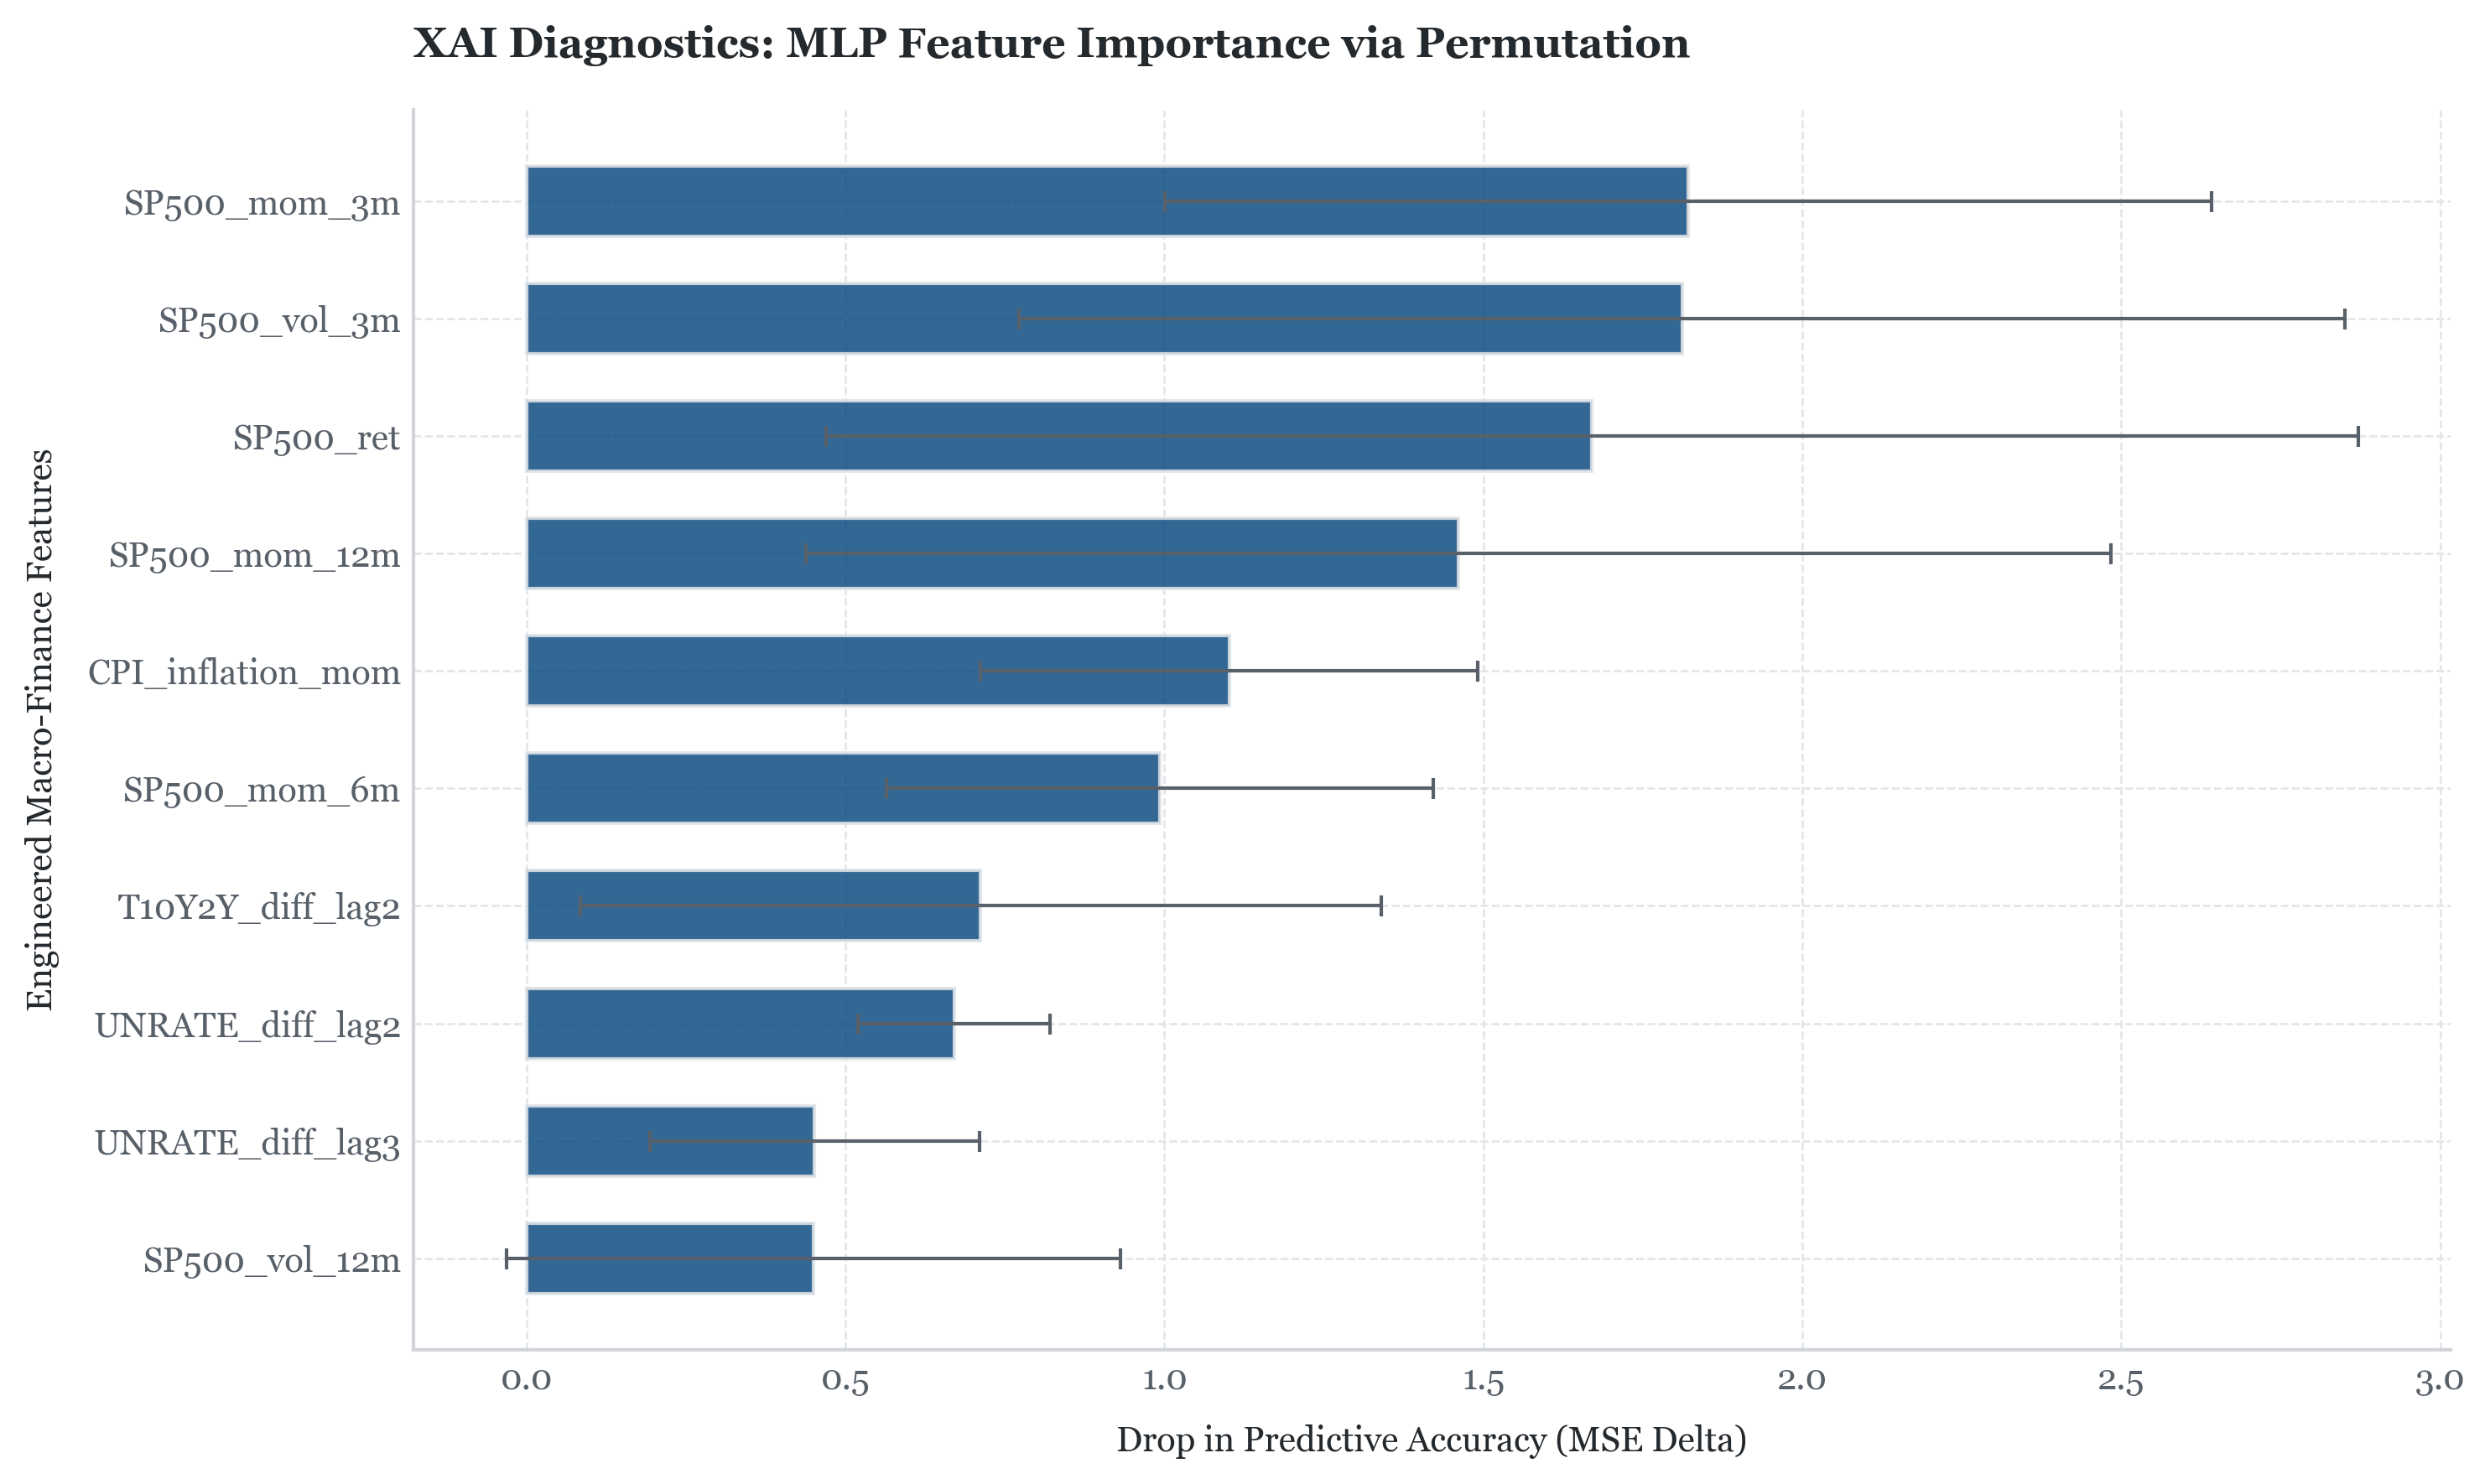

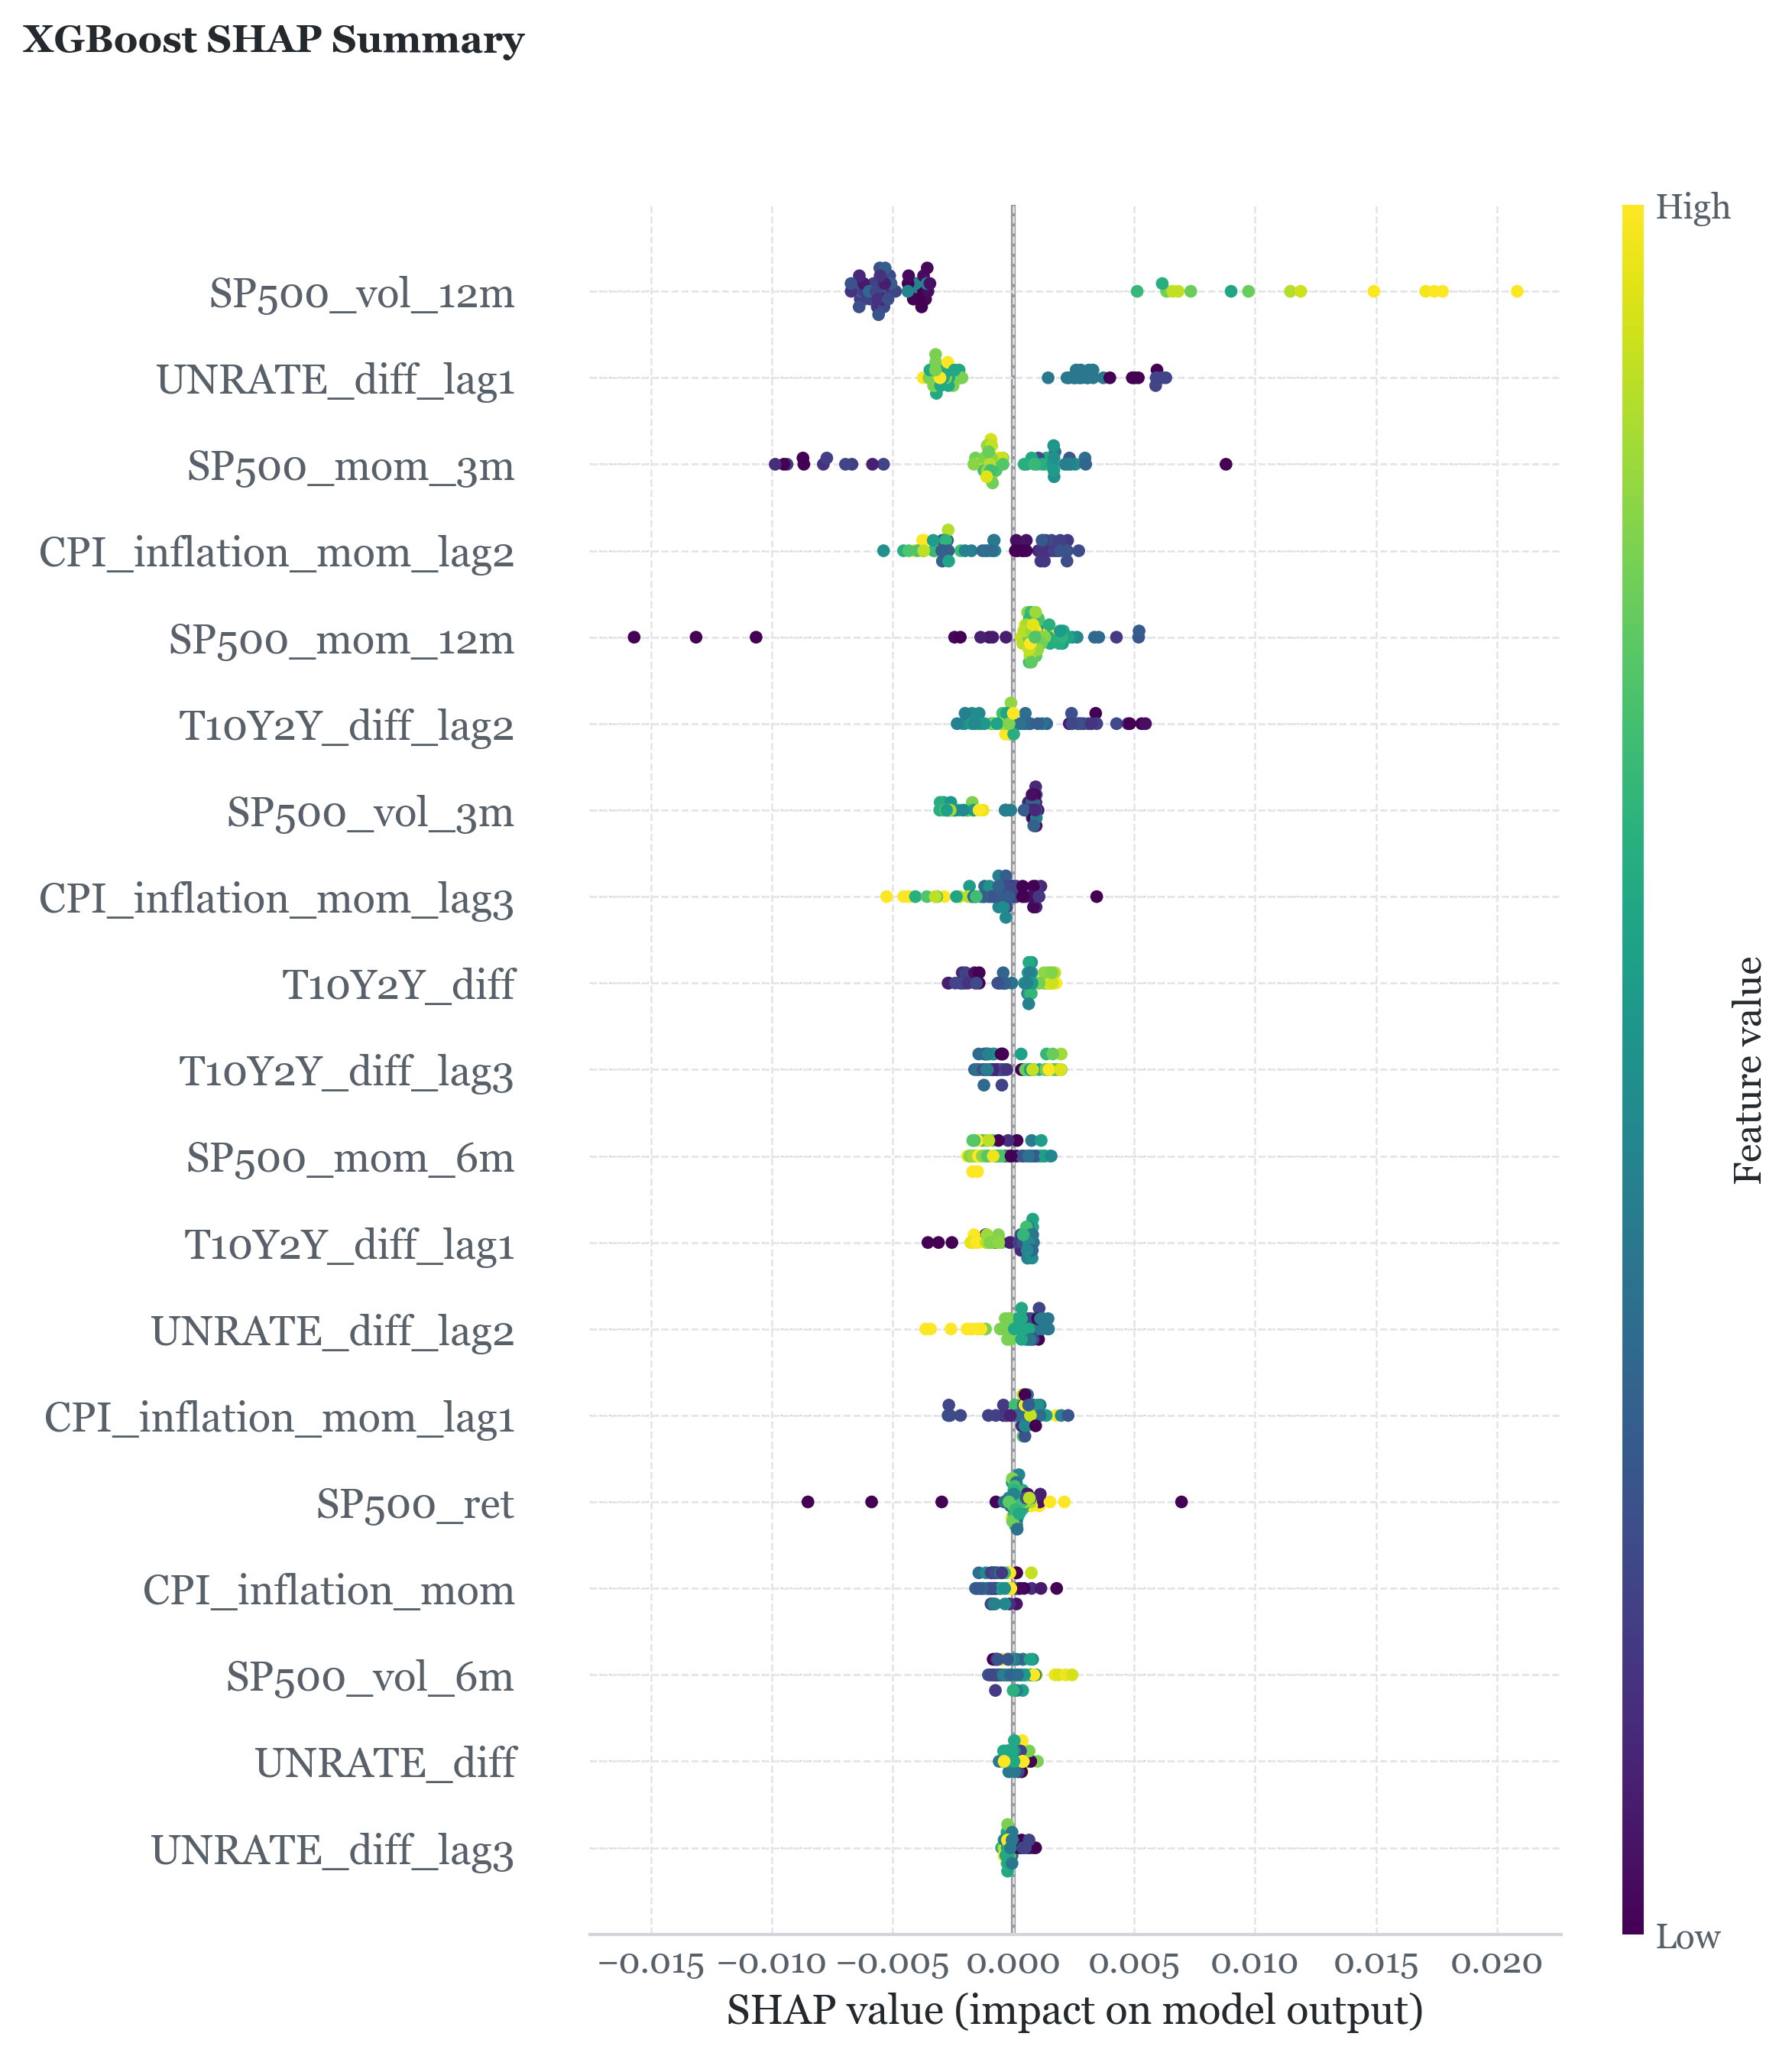

=== XGBoost Feature Importance (SHAP) ===


,Feature,Importance
0,SP500_vol_12m,0.00663
1,UNRATE_diff_lag1,0.00331
2,SP500_mom_3m,0.00259
3,CPI_inflation_mom_lag2,0.00211
4,SP500_mom_12m,0.00200
5,T10Y2Y_diff_lag2,0.00148
6,SP500_vol_3m,0.00137
7,CPI_inflation_mom_lag3,0.00125
8,T10Y2Y_diff,0.00115
9,T10Y2Y_diff_lag3,0.00106


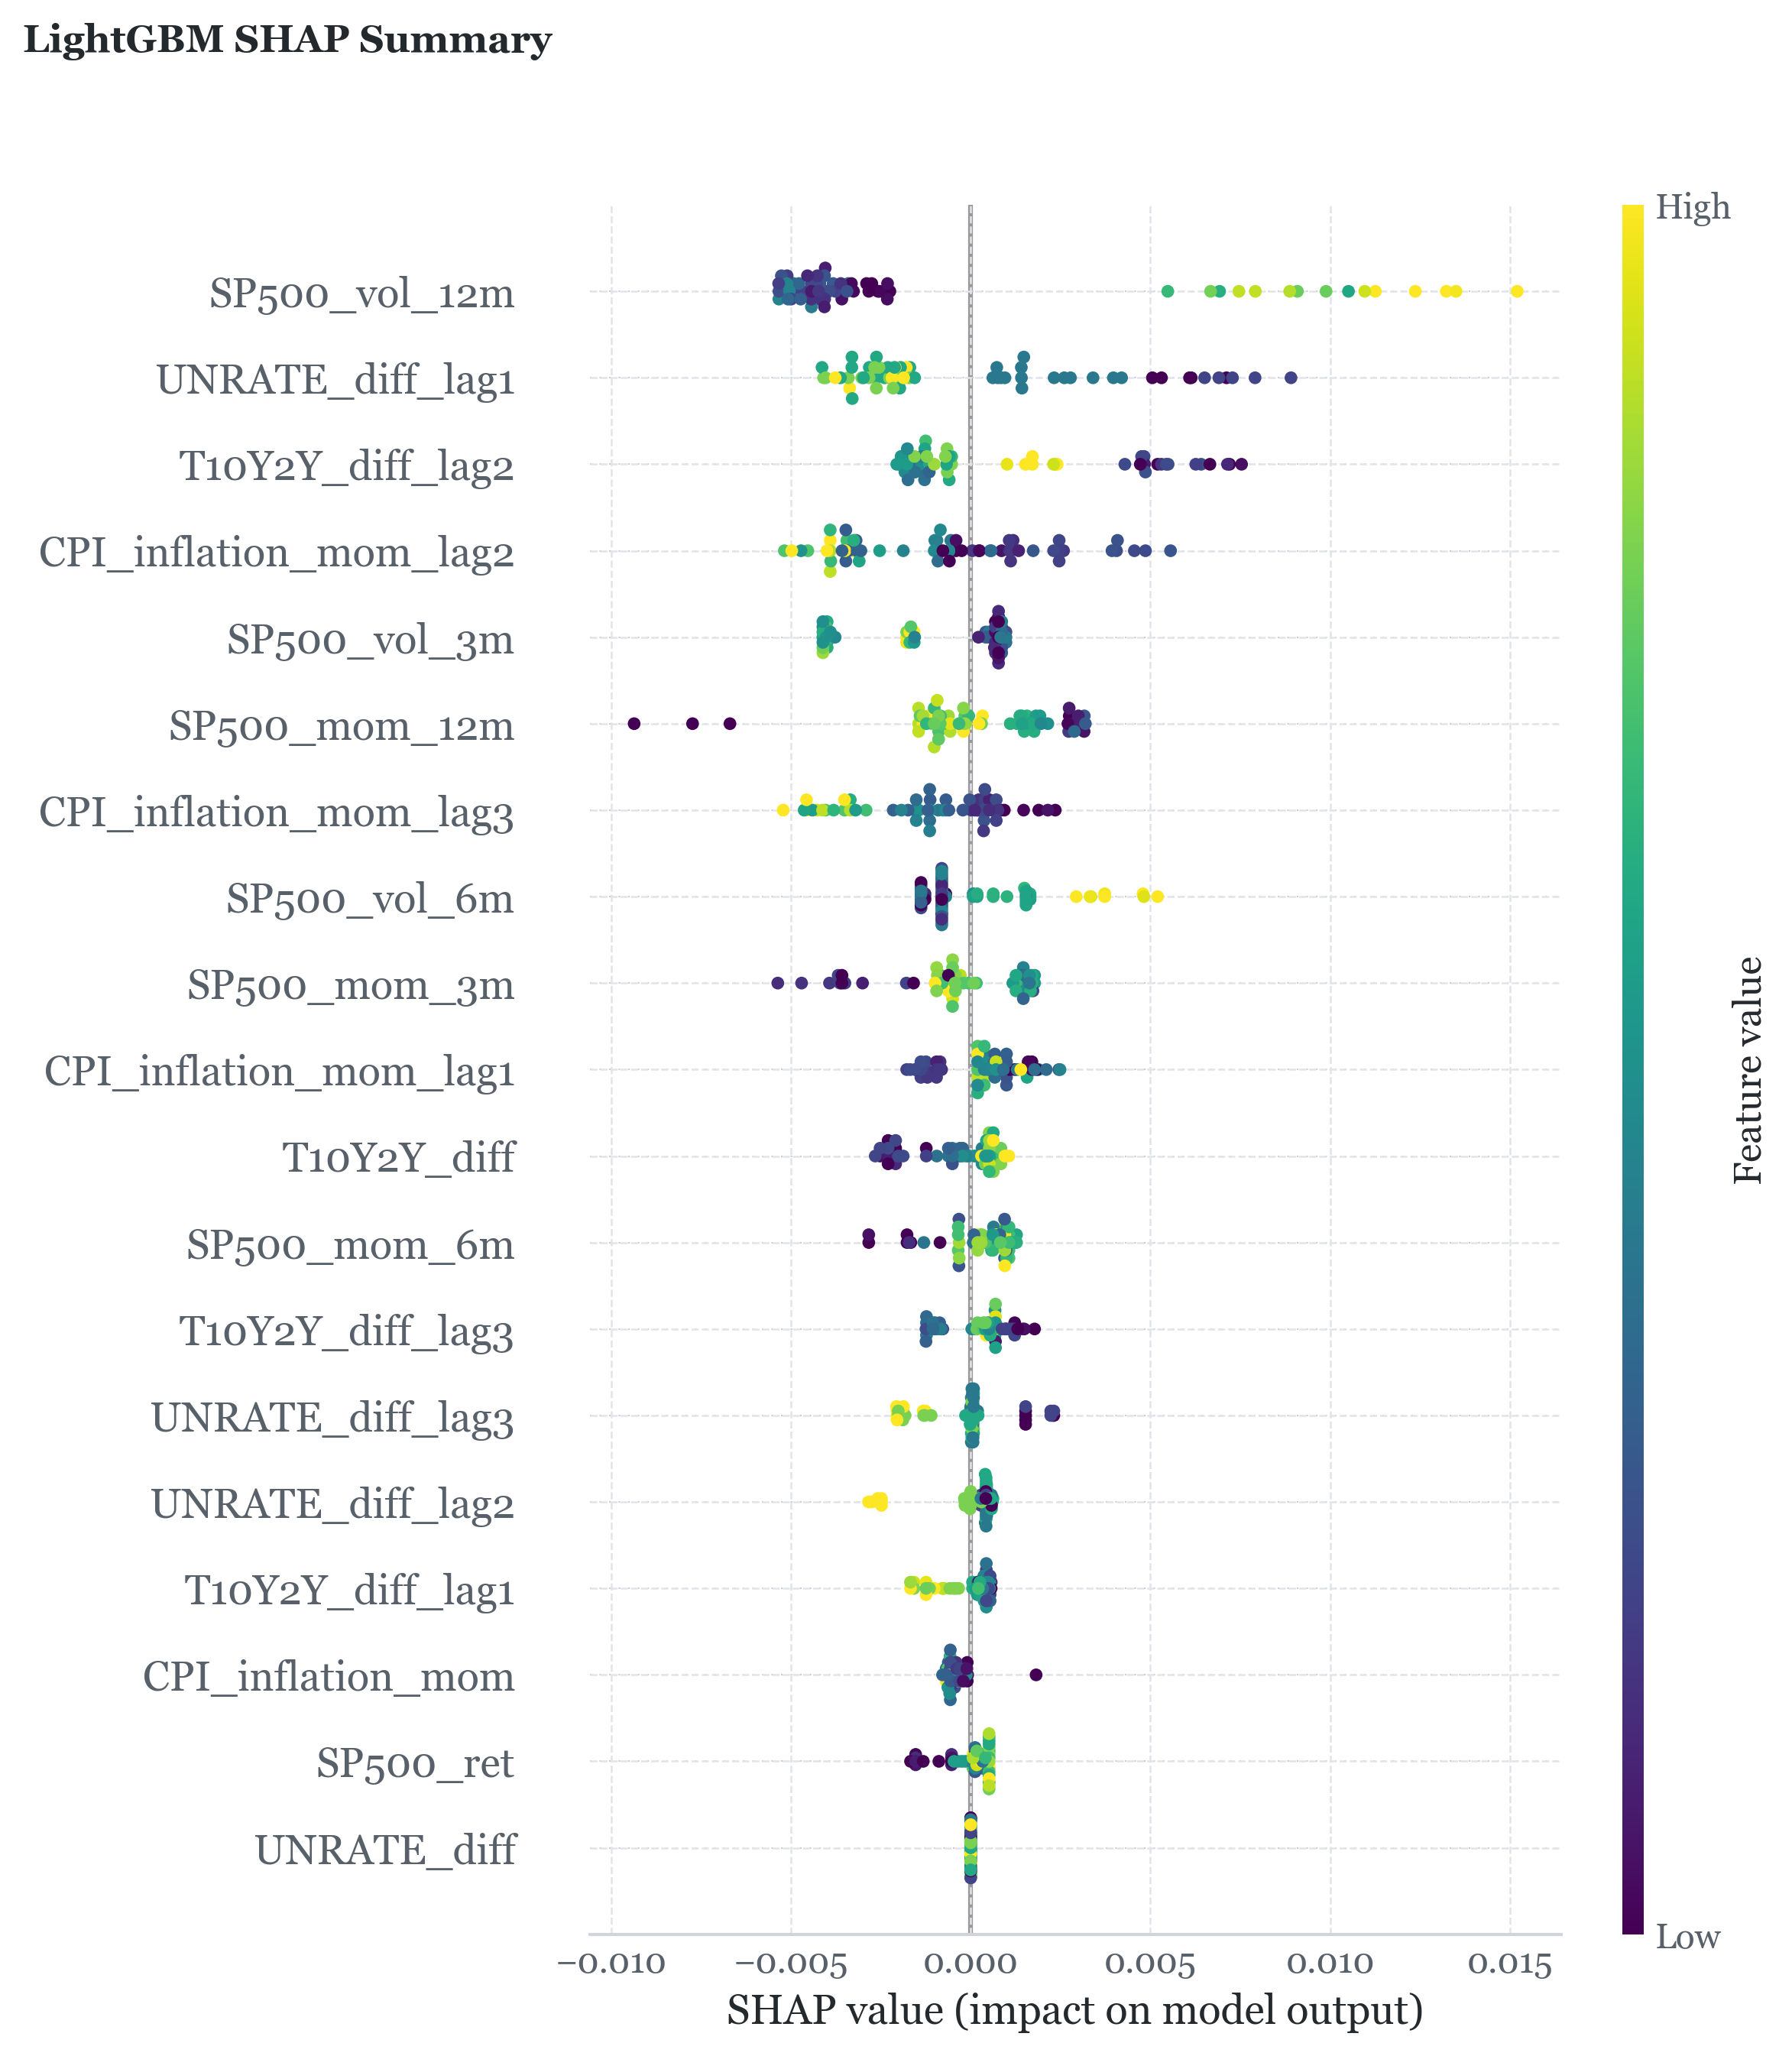

=== LightGBM Feature Importance (SHAP) ===


,Feature,Importance
0,SP500_vol_12m,0.00551
1,UNRATE_diff_lag1,0.00314
2,T10Y2Y_diff_lag2,0.00253
3,CPI_inflation_mom_lag2,0.00241
4,SP500_vol_3m,0.00176
5,SP500_mom_12m,0.00172
6,CPI_inflation_mom_lag3,0.00166
7,SP500_vol_6m,0.00141
8,SP500_mom_3m,0.00141
9,CPI_inflation_mom_lag1,0.00103


In [72]:
plt.figure(figsize=(10, 6), dpi=300)

top_xai = df_xai.head(10).sort_values(by='Importance_Mean', ascending=True)

plt.barh(top_xai['Feature'], top_xai['Importance_Mean'],
         xerr=top_xai['Importance_Std'],
         color='#0f4c81', alpha=0.85, edgecolor='#e1e4e8', height=0.6,
         error_kw={'ecolor': '#586069', 'linewidth': 1, 'capsize': 3})

plt.title('XAI Diagnostics: MLP Feature Importance via Permutation', loc='left', fontsize=12, fontweight='bold', color='#24292e', pad=15)
plt.xlabel('Drop in Predictive Accuracy (MSE Delta)', fontsize=10, labelpad=8)
plt.ylabel('Engineered Macro-Finance Features', fontsize=10, labelpad=8)
plt.grid(True, axis='x', color='#e1e4e8', linestyle='--', linewidth=0.6)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#d1d5da')
ax.spines['bottom'].set_color('#d1d5da')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'xai_feature_importance.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()

for boosting_name in ['XGBoost', 'LightGBM']:
    if boosting_name not in model_pipeline.trained_models:
        continue

    estimator = model_pipeline.get_estimator(boosting_name)
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    plt.figure(figsize=(10, 6), dpi=300)
    shap.summary_plot(shap_values, X_test, show=False, plot_type='dot', cmap='viridis')

    fig = plt.gcf()
    fig.patch.set_facecolor('#ffffff')

    for ax_plot in fig.get_axes():
        ax_plot.patch.set_facecolor('#ffffff')
        ax_plot.tick_params(colors='#586069')
        ax_plot.xaxis.label.set_color('#24292e')
        ax_plot.yaxis.label.set_color('#24292e')
        ax_plot.title.set_color('#24292e')
        ax_plot.spines['top'].set_visible(False)
        ax_plot.spines['right'].set_visible(False)
        ax_plot.spines['left'].set_color('#d1d5da')
        ax_plot.spines['bottom'].set_color('#d1d5da')

    plt.suptitle(f'{boosting_name} SHAP Summary', x=0.01, ha='left', fontsize=12, fontweight='bold', color='#24292e', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(FIGURES_DIR, f'{boosting_name.lower()}_shap_summary.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
    plt.show()

    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': np.abs(shap_values).mean(axis=0),
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    print(f'=== {boosting_name} Feature Importance (SHAP) ===')
    display(feature_importance.head(10).round(5))
